# Neuro-Genomic AI — Demo Interface

> **⚠️ RESEARCH PROTOTYPE — NOT FOR CLINICAL USE**  
> All outputs from this notebook are exploratory research results only.  
> They must not be used for clinical diagnosis, screening, or any medical decision-making.  
> No clinical thresholds are encoded. All index values require expert interpretation.

This notebook demonstrates the full Neuro-Genomic AI pipeline end-to-end:
1. Load HRV features from database
2. Compute maturation index with 95% confidence interval
3. Visualize signal quality and uncertainty
4. Display multi-modal data overview

In [1]:
# Imports and configuration
import sqlite3
import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')

# -- Paths ---------------------------------------------------------------------
ROOT = Path('..').resolve()
DB_PATH = ROOT / 'data' / 'processed' / 'neuro_genomic.db'
sys.path.insert(0, str(ROOT / 'src'))

from scoring_model import MaturationIndex

print(f"Python {sys.version}")
print(f"DB path: {DB_PATH}  exists={DB_PATH.exists()}")

Python 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
DB path: C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\data\processed\neuro_genomic.db  exists=True


In [2]:
# -- Load HRV features from DB (or fall back to synthetic) ---------------------
def _normalize_hrv_schema(df):
    # Case A: already in demo schema
    required_demo = {'heart_rate_mean', 'rmssd', 'pnn50'}
    if required_demo.issubset(df.columns):
        out = df.copy()
        if 'signal_name' not in out.columns:
            out['signal_name'] = [f'fetal_ecg_{i+1}' for i in range(len(out))]
        if 'num_beats' not in out.columns:
            out['num_beats'] = np.nan
        return out

    # Case B: current DB schema from feature extraction notebook
    required_db = {'fet_heart_rate_mean', 'fet_rmssd', 'fet_pnn50'}
    if required_db.issubset(df.columns):
        out = pd.DataFrame({
            'signal_name': [f'fetal_window_{i+1}' for i in range(len(df))],
            'heart_rate_mean': df['fet_heart_rate_mean'],
            'rmssd': df['fet_rmssd'],
            'pnn50': df['fet_pnn50'],
            'num_beats': df['fet_num_beats'] if 'fet_num_beats' in df.columns else np.nan,
        })
        return out

    raise ValueError('HRV table schema not recognized for demo interface.')


def load_hrv_features(db_path):
    if db_path.exists():
        try:
            with sqlite3.connect(db_path) as conn:
                cursor = conn.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='hrv_feature_matrix'")
                if cursor.fetchone():
                    df_raw = pd.read_sql_query("SELECT * FROM hrv_feature_matrix", conn)
                    if not df_raw.empty:
                        df = _normalize_hrv_schema(df_raw)
                        print(f"Loaded {len(df)} HRV records from database.")
                        return df
        except Exception as e:
            print(f"DB load failed: {e}")

    # Synthetic fallback -- representative fetal HRV values
    print("Using synthetic HRV data (DB not available or table empty).")
    np.random.seed(42)
    records = []
    for i in range(5):
        records.append({
            'signal_name': f'fetal_ecg_{i+1}',
            'heart_rate_mean': np.random.uniform(125, 158),
            'heart_rate_std': np.random.uniform(5, 15),
            'rr_interval_mean': np.random.uniform(380, 480),
            'rr_interval_std': np.random.uniform(20, 60),
            'rmssd': np.random.uniform(8, 35),
            'pnn50': np.random.uniform(3, 18),
            'num_beats': np.random.randint(20, 40),
        })
    return pd.DataFrame(records)


hrv_df = load_hrv_features(DB_PATH)
print(hrv_df[['signal_name', 'heart_rate_mean', 'rmssd', 'pnn50', 'num_beats']].head())

Loaded 180 HRV records from database.
      signal_name  heart_rate_mean       rmssd      pnn50  num_beats
0  fetal_window_1        74.418605  126.755352  25.000000         13
1  fetal_window_2        73.265495   29.475874   0.000000         12
2  fetal_window_3        74.296435   31.914237   9.090909         12
3  fetal_window_4        73.423980   34.971329   9.090909         12
4  fetal_window_5        73.552781   21.005183   0.000000         13


In [3]:
# ── Compute maturation index for each HRV record ───────────────────────────────
mi = MaturationIndex(n_bootstrap=500)

results = []
for _, row in hrv_df.iterrows():
    features = {
        'heart_rate_mean': row.get('heart_rate_mean', np.nan),
        'rmssd': row.get('rmssd', np.nan),
        'pnn50': row.get('pnn50', np.nan),
    }
    result = mi.compute(features)
    result['signal_name'] = row.get('signal_name', 'unknown')
    result['num_beats'] = row.get('num_beats', np.nan)
    results.append(result)

results_df = pd.DataFrame(results)

# Flag: unreliable if < 30 beats, or CI width > 0.3
results_df['reliable'] = (results_df['num_beats'] >= 30) & (results_df['ci_width'] < 0.3)
results_df['uncertainty'] = results_df['ci_width'].apply(
    lambda w: 'Low' if w < 0.15 else ('Moderate' if w < 0.3 else 'High')
)

cols = ['signal_name', 'score', 'ci_lower', 'ci_upper', 'ci_width', 'uncertainty', 'reliable']
print(results_df[cols].to_string(index=False))

     signal_name    score  ci_lower  ci_upper  ci_width uncertainty  reliable
  fetal_window_1 0.714286  0.714286  0.714286  0.000000         Low     False
  fetal_window_2 0.299705  0.386709  0.447717  0.061008         Low     False
  fetal_window_3 0.459432  0.436444  0.482477  0.046033         Low     False
  fetal_window_4 0.496866  0.471616  0.522638  0.051022         Low     False
  fetal_window_5 0.195982  0.251737  0.297163  0.045426         Low     False
  fetal_window_6 0.385903  0.367504  0.405866  0.038362         Low     False
  fetal_window_7 0.213002  0.275724  0.319639  0.043914         Low     False
  fetal_window_8 0.250347  0.324364  0.376354  0.051990         Low     False
  fetal_window_9 0.213002  0.275889  0.321217  0.045329         Low     False
 fetal_window_10 0.262709  0.343046  0.394715  0.051669         Low     False
 fetal_window_11 0.245241  0.319295  0.370644  0.051349         Low     False
 fetal_window_12 0.558442  0.550275  0.566401  0.016127         

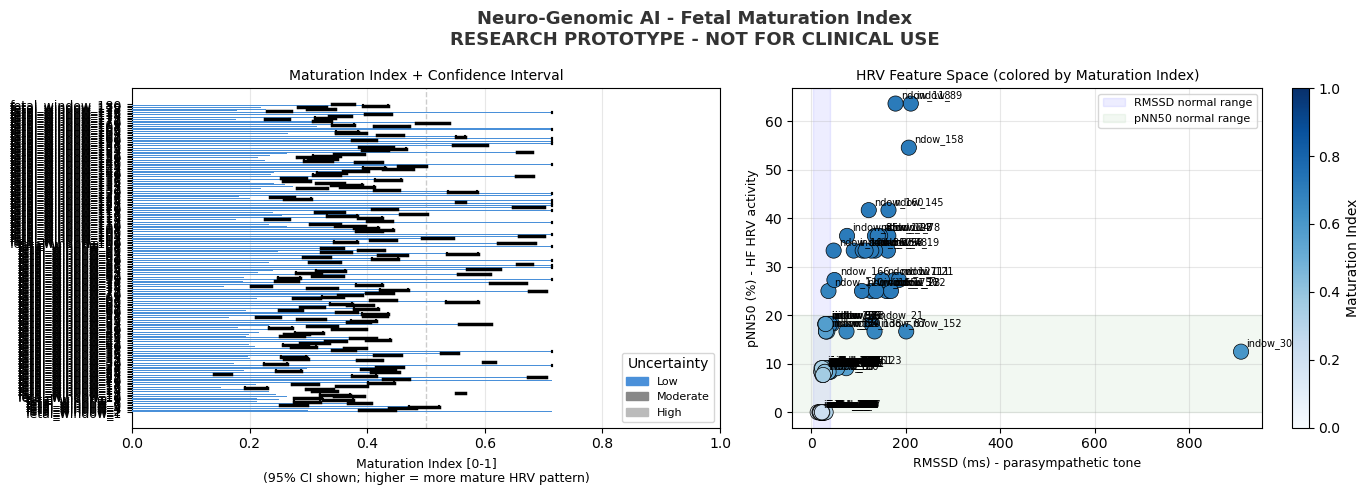

Figure saved to C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\data\processed\maturation_index_demo.png


In [5]:
# -- Maturation Index Visualization --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neuro-Genomic AI - Fetal Maturation Index\n'
             'RESEARCH PROTOTYPE - NOT FOR CLINICAL USE',
             fontsize=13, fontweight='bold', color='#333')

# Panel 1: Index + CI bar chart
ax = axes[0]
labels = results_df['signal_name'].astype(str)
scores = results_df['score'].values
ci_lo = results_df['ci_lower'].values
ci_hi = results_df['ci_upper'].values
y_pos = np.arange(len(labels))

# Color by uncertainty
colour_map = {'Low': '#4a90d9', 'Moderate': '#888', 'High': '#bbb'}
bar_colours = [colour_map[u] for u in results_df['uncertainty']]
ax.barh(y_pos, scores, color=bar_colours, height=0.5, zorder=3)
for i, (lo, hi) in enumerate(zip(ci_lo, ci_hi)):
    ax.plot([lo, hi], [i, i], 'k-', linewidth=2.5, zorder=4)
    ax.plot([lo, lo], [i - 0.2, i + 0.2], 'k-', linewidth=1.5, zorder=4)
    ax.plot([hi, hi], [i - 0.2, i + 0.2], 'k-', linewidth=1.5, zorder=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('Maturation Index [0-1]\n(95% CI shown; higher = more mature HRV pattern)', fontsize=9)
ax.set_title('Maturation Index + Confidence Interval', fontsize=10)
ax.axvline(0.5, color='#ccc', linestyle='--', linewidth=1, zorder=2)
ax.grid(axis='x', alpha=0.3, zorder=1)

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in colour_map.items()]
ax.legend(handles=legend_handles, title='Uncertainty', fontsize=8, loc='lower right')

# Panel 2: HRV feature scatter (RMSSD vs pNN50)
ax2 = axes[1]
sc = ax2.scatter(
    hrv_df['rmssd'], hrv_df['pnn50'],
    c=results_df['score'], cmap='Blues', s=120, edgecolors='k', linewidths=0.5,
    vmin=0, vmax=1, zorder=3
)
plt.colorbar(sc, ax=ax2, label='Maturation Index')
ax2.axvspan(5, 40, alpha=0.07, color='blue', label='RMSSD normal range')
ax2.axhspan(0, 20, alpha=0.05, color='green', label='pNN50 normal range')
for _, row in hrv_df.iterrows():
    ax2.annotate(
        row.get('signal_name', '')[-8:],
        (row['rmssd'], row['pnn50']),
        fontsize=7,
        xytext=(4, 4),
        textcoords='offset points'
    )
ax2.set_xlabel('RMSSD (ms) - parasympathetic tone', fontsize=9)
ax2.set_ylabel('pNN50 (%) - HF HRV activity', fontsize=9)
ax2.set_title('HRV Feature Space (colored by Maturation Index)', fontsize=10)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

output_path = ROOT / 'data' / 'processed' / 'maturation_index_demo.png'
output_path.parent.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(output_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Figure saved to {output_path}')

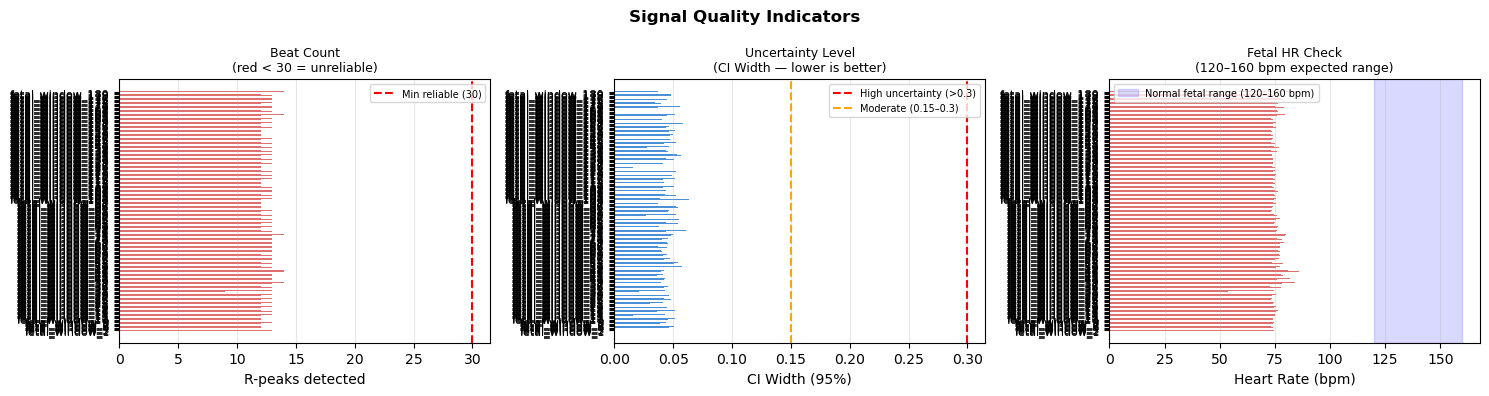

In [6]:
# ── Signal Quality Dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Signal Quality Indicators', fontsize=12, fontweight='bold')

beat_counts = hrv_df['num_beats'].values if 'num_beats' in hrv_df.columns else np.full(len(hrv_df), np.nan)
labels = hrv_df['signal_name'].astype(str).values
y_pos = np.arange(len(labels))

# Panel 1: Beat count reliability
ax = axes[0]
threshold = 30
beat_colours = ['#4a90d9' if b >= threshold else '#e07070' for b in beat_counts]
ax.barh(y_pos, beat_counts, color=beat_colours, height=0.5)
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Min reliable ({threshold})')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('R-peaks detected')
ax.set_title('Beat Count\n(red < 30 = unreliable)', fontsize=9)
ax.legend(fontsize=7)
ax.grid(axis='x', alpha=0.3)

# Panel 2: HRV CI width (uncertainty)
ax2 = axes[1]
ci_widths = results_df['ci_width'].values
ci_colours = ['#4a90d9' if w < 0.15 else ('#f0a830' if w < 0.3 else '#e07070') for w in ci_widths]
ax2.barh(y_pos, ci_widths, color=ci_colours, height=0.5)
ax2.axvline(0.3, color='red', linestyle='--', linewidth=1.5, label='High uncertainty (>0.3)')
ax2.axvline(0.15, color='orange', linestyle='--', linewidth=1.5, label='Moderate (0.15–0.3)')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels, fontsize=8)
ax2.set_xlabel('CI Width (95%)')
ax2.set_title('Uncertainty Level\n(CI Width — lower is better)', fontsize=9)
ax2.legend(fontsize=7)
ax2.grid(axis='x', alpha=0.3)

# Panel 3: Heart rate range check (120–160 fetal expected range)
ax3 = axes[2]
hr_vals = hrv_df['heart_rate_mean'].values if 'heart_rate_mean' in hrv_df.columns else np.full(len(hrv_df), np.nan)
hr_ok = [(120 <= hr <= 160) for hr in hr_vals]
hr_colours = ['#4a90d9' if ok else '#e07070' for ok in hr_ok]
ax3.barh(y_pos, hr_vals, color=hr_colours, height=0.5)
ax3.axvspan(120, 160, alpha=0.15, color='blue', label='Normal fetal range (120–160 bpm)')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(labels, fontsize=8)
ax3.set_xlabel('Heart Rate (bpm)')
ax3.set_title('Fetal HR Check\n(120–160 bpm expected range)', fontsize=9)
ax3.legend(fontsize=7)
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# ── Multi-modal data overview ───────────────────────────────────────────────────
if DB_PATH.exists():
    try:
        with sqlite3.connect(DB_PATH) as conn:
            tables = pd.read_sql_query(
                "SELECT name FROM sqlite_master WHERE type='table'", conn
            )['name'].tolist()
            print(f"Tables in DB: {tables}\n")
            for table in tables:
                try:
                    count = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {table}", conn)['n'][0]
                    cols_info = pd.read_sql_query(f"PRAGMA table_info({table})", conn)
                    col_names = cols_info['name'].tolist()
                    print(f"  {table}: {count} rows | columns: {col_names}")
                except Exception:
                    pass
    except Exception as e:
        print(f"Could not read DB: {e}")
else:
    print("Database not found — run notebooks 01–03 first to populate the database.")

Tables in DB: ['physio_data', 'genomic_data', 'behavioral_data', 'separated_components', 'hrv_feature_matrix']

  physio_data: 650000 rows | columns: ['sample_index', 'time_sec', 'MLII', 'V5', 'record_name', 'database', 'sampling_rate']
  genomic_data: 650 rows | columns: ['sample_id', 'gene_expression_a', 'gene_expression_b', 'gene_expression_c', 'variant_load']
  behavioral_data: 650 rows | columns: ['task_id', 'click_rate', 'typing_speed', 'error_rate', 'focus_score']
  separated_components: 650000 rows | columns: ['sample_index', 'time_sec', 'maternal_ecg', 'fetal_ecg', 'maternal_component_index', 'fetal_component_index', 'maternal_component_freq_hz', 'fetal_component_freq_hz']
  hrv_feature_matrix: 180 rows | columns: ['window_start', 'window_end', 'mat_heart_rate_mean', 'mat_rmssd', 'mat_pnn50', 'fet_heart_rate_mean', 'fet_rmssd', 'fet_pnn50', 'mat_num_beats', 'fet_num_beats', 'target']


In [8]:
# ── Summary report ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  NEURO-GENOMIC AI — MATURATION INDEX SUMMARY REPORT")
print("  ⚠  RESEARCH PROTOTYPE — NOT FOR CLINICAL USE")
print("=" * 65)

for _, row in results_df.iterrows():
    score = row['score']
    score_str = f"{score:.3f}" if score is not None else "N/A"
    ci_str = f"[{row['ci_lower']:.3f}, {row['ci_upper']:.3f}]"
    reliable_str = "✓" if row['reliable'] else "⚠ (low beat count or high CI)"
    print(f"\n  Signal : {row['signal_name']}")
    print(f"  Index  : {score_str}  95% CI {ci_str}")
    print(f"  Uncert : {row['uncertainty']} (CI width = {row['ci_width']:.3f})")
    print(f"  Quality: {reliable_str}")

print("\n" + "=" * 65)
print("  DISCLAIMER:", results_df['disclaimer'].iloc[0])
print("=" * 65)

  NEURO-GENOMIC AI — MATURATION INDEX SUMMARY REPORT
  ⚠  RESEARCH PROTOTYPE — NOT FOR CLINICAL USE

  Signal : fetal_window_1
  Index  : 0.714  95% CI [0.714, 0.714]
  Uncert : Low (CI width = 0.000)
  Quality: ⚠ (low beat count or high CI)

  Signal : fetal_window_2
  Index  : 0.300  95% CI [0.387, 0.448]
  Uncert : Low (CI width = 0.061)
  Quality: ⚠ (low beat count or high CI)

  Signal : fetal_window_3
  Index  : 0.459  95% CI [0.436, 0.482]
  Uncert : Low (CI width = 0.046)
  Quality: ⚠ (low beat count or high CI)

  Signal : fetal_window_4
  Index  : 0.497  95% CI [0.472, 0.523]
  Uncert : Low (CI width = 0.051)
  Quality: ⚠ (low beat count or high CI)

  Signal : fetal_window_5
  Index  : 0.196  95% CI [0.252, 0.297]
  Uncert : Low (CI width = 0.045)
  Quality: ⚠ (low beat count or high CI)

  Signal : fetal_window_6
  Index  : 0.386  95% CI [0.368, 0.406]
  Uncert : Low (CI width = 0.038)
  Quality: ⚠ (low beat count or high CI)

  Signal : fetal_window_7
  Index  : 0.213  95%